In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [22]:
news_df = pd.read_csv("/content/train.csv")
#news_df = pd.read_csv("/content/train.csv", engine='python', on_bad_lines='skip')
#news_df = pd.read_csv("/content/train.csv", encoding='latin1', engine='python', on_bad_lines='skip')


In [23]:
news_df.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [24]:
news_df.shape

(20800, 5)

In [25]:
news_df.isna().sum()


,0
id,0
title,558
author,1957
text,39
label,0


In [26]:
news_df = news_df.fillna(' ')


In [27]:
news_df.isna().sum()


,0
id,0
title,0
author,0
text,0
label,0


In [28]:
news_df['content'] = news_df['author'] + " " + news_df['title']


In [29]:
news_df

,id,title,author,text,label,content
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1,Darrell Lucus House Dem Aide: We Didn’t Even S...
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0,"Daniel J. Flynn FLYNN: Hillary Clinton, Big Wo..."
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1,Consortiumnews.com Why the Truth Might Get You...
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1,Jessica Purkiss 15 Civilians Killed In Single ...
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1,Howard Portnoy Iranian woman jailed for fictio...
...,...,...,...,...,...,...
20795,20795,Rapper T.I.: Trump a ’Poster Child For White S...,Jerome Hudson,Rapper T. I. unloaded on black celebrities who...,0,Jerome Hudson Rapper T.I.: Trump a ’Poster Chi...
20796,20796,"N.F.L. Playoffs: Schedule, Matchups and Odds -...",Benjamin Hoffman,When the Green Bay Packers lost to the Washing...,0,"Benjamin Hoffman N.F.L. Playoffs: Schedule, Ma..."
20797,20797,Macy’s Is Said to Receive Takeover Approach by...,Michael J. de la Merced and Rachel Abrams,The Macy’s of today grew from the union of sev...,0,Michael J. de la Merced and Rachel Abrams Macy...
20798,20798,"NATO, Russia To Hold Parallel Exercises In Bal...",Alex Ansary,"NATO, Russia To Hold Parallel Exercises In Bal...",1,"Alex Ansary NATO, Russia To Hold Parallel Exer..."


In [30]:
news_df['content']

,content
0,Darrell Lucus House Dem Aide: We Didn’t Even S...
1,"Daniel J. Flynn FLYNN: Hillary Clinton, Big Wo..."
2,Consortiumnews.com Why the Truth Might Get You...
3,Jessica Purkiss 15 Civilians Killed In Single ...
4,Howard Portnoy Iranian woman jailed for fictio...
...,...
20795,Jerome Hudson Rapper T.I.: Trump a ’Poster Chi...
20796,"Benjamin Hoffman N.F.L. Playoffs: Schedule, Ma..."
20797,Michael J. de la Merced and Rachel Abrams Macy...
20798,"Alex Ansary NATO, Russia To Hold Parallel Exer..."


In [35]:
# stemming
ps = PorterStemmer()
def stemming(content):
    stemmed_content = re.sub('[^a-zA-Z]',' ',content)
    stemmed_content = stemmed_content.lower()
    stemmed_content = stemmed_content.split()
    stemmed_content = [ps.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
    stemmed_content = ' '.join(stemmed_content)
    return stemmed_content

In [36]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [37]:
news_df['content'] = news_df['content'].apply(stemming)

In [38]:
news_df['content']

,content
0,darrel lucu hou dem aid even see comey letter ...
1,daniel j flynn flynn hillari clinton big woman...
2,consortiumnew com truth might get fire
3,jessica purkiss civilian kill singl us airstri...
4,howard portnoy iranian woman jail fiction unpu...
...,...
20795,jerom hudson rapper trump poster child white s...
20796,benjamin hoffman n f l playoff schedul matchup...
20797,michael j de la merc rachel abram maci said re...
20798,alex ansari nato russia hold parallel exerci b...


In [39]:
X = news_df['content'].values
y = news_df['label'].values

In [40]:
print(X)

['darrel lucu hou dem aid even see comey letter jason chaffetz tweet'
 'daniel j flynn flynn hillari clinton big woman campu breitbart'
 'consortiumnew com truth might get fire' ...
 'michael j de la merc rachel abram maci said receiv takeov approach hudson bay new york time'
 'alex ansari nato russia hold parallel exerci balkan'
 'david swanson keep f aliv']


In [41]:
print(y)

[1 0 1 ... 0 1 1]


In [42]:
vector = TfidfVectorizer()
X = vector.fit_transform(X)

In [43]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 210584 stored elements and shape (20800, 16984)>
  Coords	Values
  (0, 3567)	0.3598939188262559
  (0, 8822)	0.3635963806326075
  (0, 6930)	0.21874169089359144
  (0, 3759)	0.2705332480845492
  (0, 263)	0.27010124977708766
  (0, 4917)	0.233316966909351
  (0, 13348)	0.2565896679337957
  (0, 2933)	0.2468450128533713
  (0, 8546)	0.29212514087043684
  (0, 7612)	0.24785219520671603
  (0, 2464)	0.3676519686797209
  (0, 15553)	0.28485063562728646
  (1, 3535)	0.2653147533915268
  (1, 5440)	0.7186013955384664
  (1, 6744)	0.19152496072048605
  (1, 2790)	0.19208753385709676
  (1, 1481)	0.2957471154505952
  (1, 16656)	0.3025156488372128
  (1, 2206)	0.36915639258038363
  (1, 1877)	0.15614790568229528
  (2, 3072)	0.46097489583229645
  (2, 2917)	0.3179886800654691
  (2, 15478)	0.41544962664721613
  (2, 9532)	0.49351492943649944
  (2, 5903)	0.3474613386728292
  :	:
  (20797, 9500)	0.17463635692029988
  (20797, 6969)	0.21809398920480086
  (207

In [44]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)


In [45]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [46]:
train_y_pred = model.predict(X_train)
print("train accurracy :",accuracy_score(train_y_pred,y_train))

train accurracy : 0.9866586538461538


In [47]:
test_y_pred = model.predict(X_test)
print("test accurracy :",accuracy_score(test_y_pred,y_test))

test accurracy : 0.9723557692307693


In [ ]:
'''prediction system

input_data = X_test[4582]
prediction = model.predict(input_data)
if prediction[0] == 1:
    print('Fake news')
else:
    print('Real news')
  '''

"prediction system\n\ninput_data = X_test[4582]\nprediction = model.predict(input_data)\nif prediction[0] == 1:\n    print('Fake news')\nelse:\n    print('Real news')\n  "

In [51]:
import random
random_index = random.randint(0, X_test.shape[0] - 1)
input_data = X_test[100]

prediction = model.predict(input_data)
if prediction[0] == 1:
    print('Fake news')
else:
    print('Real news')

Fake news


In [53]:
news_df['content'][100]

'activist post technocraci real reason un want control internet'

In [54]:
news_df['content']

,content
0,darrel lucu hou dem aid even see comey letter ...
1,daniel j flynn flynn hillari clinton big woman...
2,consortiumnew com truth might get fire
3,jessica purkiss civilian kill singl us airstri...
4,howard portnoy iranian woman jail fiction unpu...
...,...
20795,jerom hudson rapper trump poster child white s...
20796,benjamin hoffman n f l playoff schedul matchup...
20797,michael j de la merc rachel abram maci said re...
20798,alex ansari nato russia hold parallel exerci b...


In [ ]:
#Data visualization

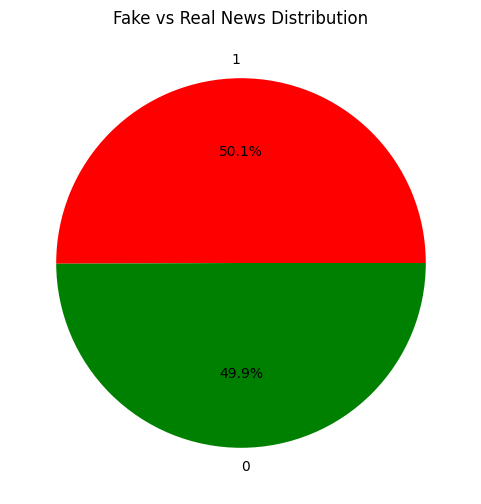

In [55]:
#pie chart
plt.figure(figsize=(6, 6))
news_df['label'].value_counts().plot.pie(autopct='%1.1f%%', colors=["red", "green"])
plt.title("Fake vs Real News Distribution")
plt.ylabel("")
plt.show()

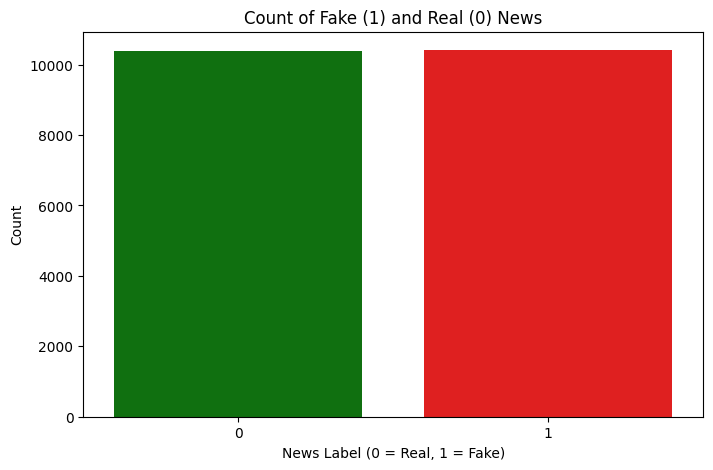

In [56]:
#Bar chart
plt.figure(figsize=(8, 5))
sns.countplot(x="label", hue="label", data=news_df, palette={0: 'green', 1: 'red'}, legend=False)
plt.title("Count of Fake (1) and Real (0) News")
plt.xlabel("News Label (0 = Real, 1 = Fake)")
plt.ylabel("Count")
plt.show()

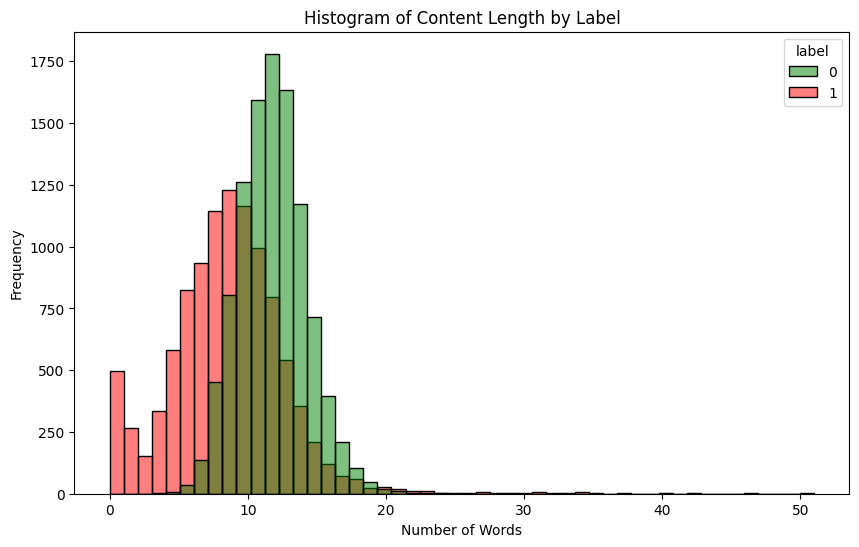

In [57]:
# Calculate content length
#news_df['content_length'] = news_df['content'].apply(lambda x: len(x.split()))
news_df['content_length'] = news_df['content'].apply(lambda x: len(str(x).split()) if not isinstance(x, float) else 0)

# Histogram - Content Length
plt.figure(figsize=(10, 6))
sns.histplot(data=news_df, x='content_length', hue='label', bins=50, palette={0: 'green', 1: 'red'})
plt.title("Histogram of Content Length by Label")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

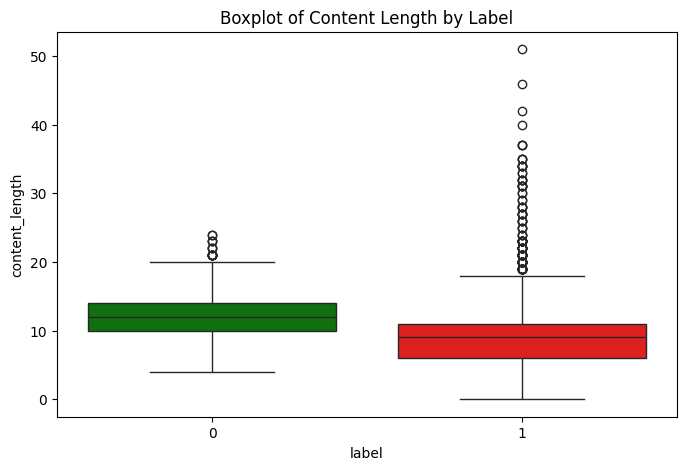

In [58]:
# Boxplot - Content Length Comparison
plt.figure(figsize=(8, 5))
sns.boxplot(x='label', y='content_length', data=news_df, hue='label', palette={np.int64(0): 'green', np.int64(1): 'red'}, legend=False)
plt.title("Boxplot of Content Length by Label")
plt.show()

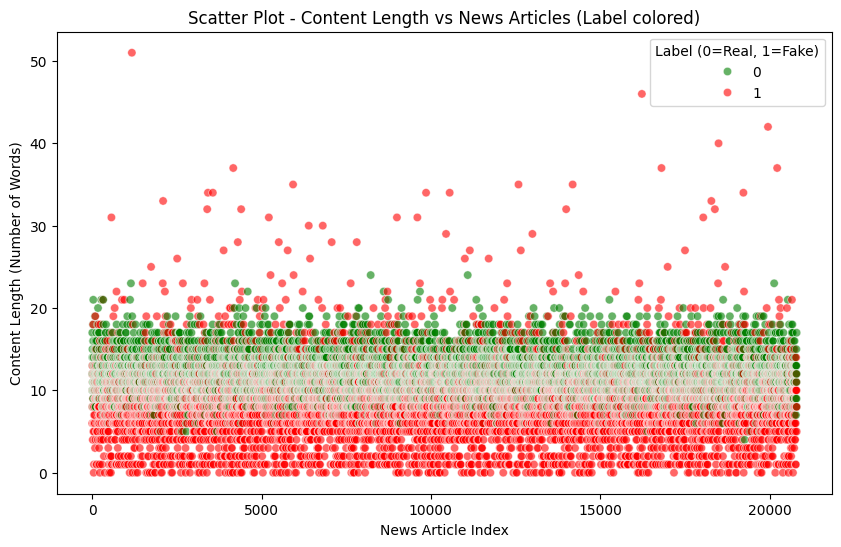

In [59]:
news_df['content_length'] = news_df['content'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.scatterplot(x=news_df.index, y='content_length', hue='label', palette={0: 'green', 1: 'red'}, data=news_df, alpha=0.6)
plt.title("Scatter Plot - Content Length vs News Articles (Label colored)")
plt.xlabel("News Article Index")
plt.ylabel("Content Length (Number of Words)")
plt.legend(title='Label (0=Real, 1=Fake)')
plt.show()